# FIFA World Cup 2026 – Analytic Task 1 Only

## Analytic question
**Did knockout-stage teams create more on-target attacking threat per unit of possession than group-stage exit teams?**

**H0:** Mean on-target threat per possession is equal between the two progression groups.  
**H1:** The two population means differ.

This notebook contains only **Task 1**.

## 1. Import libraries and helper functions

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

RANDOM_STATE = 42
ALPHA = 0.05

def make_unique(columns):
    counts = {}
    out = []
    for col in columns:
        col = str(col).replace("▼", "").strip()
        if col in counts:
            counts[col] += 1
            out.append(f"{col}.{counts[col]}")
        else:
            counts[col] = 0
            out.append(col)
    return out

def read_fbref_csv(path):
    df = pd.read_csv(path, header=1)
    df.columns = make_unique(df.columns)
    df = df.loc[:, ~df.columns.astype(str).str.match("^Unnamed")]
    for c in df.columns:
        if c not in ["Player", "Pos", "Squad", "Club", "Matches"]:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df.dropna(how="all").reset_index(drop=True)

def ci_mean(x, confidence=0.95):
    x = pd.Series(x).dropna().astype(float)
    n = len(x)
    mean = x.mean()
    sd = x.std(ddof=1)
    se = sd / np.sqrt(n)
    tcrit = stats.t.ppf((1 + confidence) / 2, n - 1)
    return pd.Series({
        "n": n, "mean": mean, "sd": sd, "se": se,
        "lower": mean - tcrit*se,
        "upper": mean + tcrit*se
    })

def welch_ci_diff(x1, x2, confidence=0.95):
    x1 = pd.Series(x1).dropna().astype(float)
    x2 = pd.Series(x2).dropna().astype(float)
    n1, n2 = len(x1), len(x2)
    m1, m2 = x1.mean(), x2.mean()
    v1, v2 = x1.var(ddof=1), x2.var(ddof=1)
    se = np.sqrt(v1/n1 + v2/n2)
    df = (v1/n1 + v2/n2)**2 / (((v1/n1)**2)/(n1-1) + ((v2/n2)**2)/(n2-1))
    tcrit = stats.t.ppf((1 + confidence) / 2, df)
    diff = m1 - m2
    return pd.Series({
        "difference": diff,
        "lower": diff - tcrit*se,
        "upper": diff + tcrit*se,
        "df": df
    })

def descriptive_table(sample, group_col, value_col):
    return sample.groupby(group_col)[value_col].agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        q1=lambda s: s.quantile(0.25),
        q3=lambda s: s.quantile(0.75),
        max="max"
    ).round(3)

def assumption_checks(g1, g2, label1, label2):
    sh1 = stats.shapiro(g1)
    sh2 = stats.shapiro(g2)
    lev = stats.levene(g1, g2)

    def outlier_count(x):
        q1, q3 = x.quantile([0.25, 0.75])
        iqr = q3 - q1
        return int(((x < q1 - 1.5*iqr) | (x > q3 + 1.5*iqr)).sum())

    return pd.Series({
        f"Shapiro p ({label1})": sh1.pvalue,
        f"Shapiro p ({label2})": sh2.pvalue,
        "Levene p": lev.pvalue,
        f"IQR outliers ({label1})": outlier_count(g1),
        f"IQR outliers ({label2})": outlier_count(g2)
    })

def stratified_sample(df, group_col, n_per_group):
    return pd.concat([
        sub.sample(n=min(n_per_group, len(sub)), random_state=RANDOM_STATE)
        for _, sub in df.groupby(group_col, sort=False)
    ], ignore_index=True)

print("Setup complete.")

Setup complete.


## 2. Load and validate the two squad datasets

In [ ]:
squad_standard = read_fbref_csv("squad_standard.csv")
squad_shooting = read_fbref_csv("squad_shooting.csv")

print("squad_standard:", squad_standard.shape)
print("squad_shooting:", squad_shooting.shape)
print("Same number of squads:", len(squad_standard) == len(squad_shooting))
print("SoT <= Sh validation:", bool((squad_shooting["SoT"] <= squad_shooting["Sh"]).all()))

display(squad_standard.head())
display(squad_shooting.head())

squad_standard: (48, 21)
squad_shooting: (48, 13)
Same number of squads: True
SoT <= Sh validation: True


,Squad,# Pl,Age,Poss,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,Gls.1,Ast.1,G+A.1,G-PK.1,G+A-PK
0,dz Algeria,22,27.3,61.0,4,44,360,4.0,5,3,8,5,0,0,3,0,1.25,0.75,2.00,1.25,2.00
1,ar Argentina,24,29.6,57.6,8,88,810,9.0,18,12,30,17,1,3,15,1,2.00,1.33,3.33,1.89,3.22
2,au Australia,23,25.3,41.0,4,44,390,4.3,2,1,3,2,0,0,5,0,0.46,0.23,0.69,0.46,0.69
3,at Austria,20,28.8,45.0,4,44,360,4.0,5,4,9,4,1,1,5,0,1.25,1.00,2.25,1.00,2.00
4,be Belgium,23,29.2,51.2,6,66,570,6.3,13,10,23,12,1,1,6,1,2.05,1.58,3.63,1.89,3.47


,Squad,# Pl,90s,Gls,Sh,SoT,SoT%,Sh/90,SoT/90,G/Sh,G/SoT,PK,PKatt
0,dz Algeria,22,4.0,5,44,15,34.1,11.00,3.75,0.11,0.33,0,0
1,ar Argentina,24,9.0,18,114,44,38.6,12.67,4.89,0.16,0.41,1,3
2,au Australia,23,4.3,2,42,12,28.6,9.69,2.77,0.05,0.17,0,0
3,at Austria,20,4.0,5,32,8,25.0,8.00,2.00,0.16,0.63,1,1
4,be Belgium,23,6.3,13,112,34,30.4,17.68,5.37,0.12,0.38,1,1


## 3. Data wrangling and engineered variable

We merge squad standard statistics with squad shooting statistics.

Tournament progression is derived from matches played:
- `MP = 3` → group-stage exit
- `MP > 3` → reached knockout stage

The engineered variable is:

\[
	ext{On-target threat per possession}
=

rac{	ext{Shots on target per 90}}{	ext{Possession \%}}	imes100
\]

In [ ]:
team_attack = squad_standard[["Squad", "Poss", "MP", "90s"]].merge(
    squad_shooting[["Squad", "Sh", "SoT", "SoT%", "Sh/90", "SoT/90"]],
    on="Squad",
    validate="one_to_one"
)

team_attack["Progression"] = np.where(
    team_attack["MP"] > 3,
    "Knockout stage",
    "Group-stage exit"
)

team_attack["OnTargetThreatPerPoss"] = (
    team_attack["SoT/90"] / team_attack["Poss"]
) * 100

display(team_attack.head())
print("\nPopulation counts:")
display(team_attack["Progression"].value_counts())

,Squad,Poss,MP,90s,Sh,SoT,SoT%,Sh/90,SoT/90,Progression,OnTargetThreatPerPoss
0,dz Algeria,61.0,4,4.0,44,15,34.1,11.00,3.75,Knockout stage,6.147541
1,ar Argentina,57.6,8,9.0,114,44,38.6,12.67,4.89,Knockout stage,8.489583
2,au Australia,41.0,4,4.3,42,12,28.6,9.69,2.77,Knockout stage,6.756098
3,at Austria,45.0,4,4.0,32,8,25.0,8.00,2.00,Knockout stage,4.444444
4,be Belgium,51.2,6,6.3,112,34,30.4,17.68,5.37,Knockout stage,10.488281



Population counts:


Progression
Knockout stage      32
Group-stage exit    16
Name: count, dtype: int64

## 4. Population, sampling frame and sampling

**Population:** all 48 FIFA World Cup 2026 squads.  
**Sampling frame:** squads with valid possession and shooting statistics.  
**Sampling method:** stratified random sampling by progression with `random_state=42`.

The 16 group-stage exits are retained and 16 knockout-stage teams are randomly sampled.

In [ ]:
task1_eligible = team_attack[
    team_attack["Poss"].notna() &
    team_attack["SoT/90"].notna() &
    np.isfinite(team_attack["OnTargetThreatPerPoss"])
].copy()

task1_sample = stratified_sample(task1_eligible, "Progression", 16)

print("Sample counts:")
display(task1_sample["Progression"].value_counts())

task1_sample.to_csv("task1_sample.csv", index=False)

Sample counts:


Progression
Knockout stage      16
Group-stage exit    16
Name: count, dtype: int64

## 5. Descriptive statistics

In [ ]:
descriptive = descriptive_table(
    task1_sample,
    "Progression",
    "OnTargetThreatPerPoss"
)
display(descriptive)

,count,mean,median,std,min,q1,q3,max
Progression,,,,,,,,
Group-stage exit,16,6.574,6.168,2.247,1.749,5.219,7.914,10.638
Knockout stage,16,9.071,8.867,2.407,5.000,7.464,10.715,13.184


## 6. 95% confidence intervals

In [ ]:
ko = task1_sample.loc[
    task1_sample["Progression"] == "Knockout stage",
    "OnTargetThreatPerPoss"
].dropna().astype(float)

ex = task1_sample.loc[
    task1_sample["Progression"] == "Group-stage exit",
    "OnTargetThreatPerPoss"
].dropna().astype(float)

print("95% CI – Knockout stage")
display(ci_mean(ko).round(3))

print("95% CI – Group-stage exit")
display(ci_mean(ex).round(3))

print("95% CI – mean difference (Knockout - Exit)")
display(welch_ci_diff(ko, ex).round(3))

95% CI – Knockout stage


n        16.000
mean      9.071
sd        2.407
se        0.602
lower     7.788
upper    10.353
dtype: float64

95% CI – Group-stage exit


n        16.000
mean      6.574
sd        2.247
se        0.562
lower     5.377
upper     7.771
dtype: float64

95% CI – mean difference (Knockout - Exit)


difference     2.497
lower          0.816
upper          4.178
df            29.859
dtype: float64

## 7. Welch two-sample t-test

In [ ]:
t_stat, p_value = stats.ttest_ind(ko, ex, equal_var=False)

print("t statistic =", round(t_stat, 5))
print("p-value =", round(p_value, 5))

if p_value < ALPHA:
    print("Decision: Reject H0 at alpha = 0.05.")
else:
    print("Decision: Fail to reject H0 at alpha = 0.05.")

t statistic = 3.03359
p-value = 0.00497
Decision: Reject H0 at alpha = 0.05.


## 8. Assumption checks and sensitivity analysis

In [ ]:
print("Assumption checks")
display(assumption_checks(ko, ex, "Knockout", "Exit").round(5))

u_stat, u_p = stats.mannwhitneyu(ko, ex, alternative="two-sided")
print("\nMann-Whitney U sensitivity check")
print("U statistic:", round(u_stat, 5))
print("p-value:", round(u_p, 5))

Assumption checks


Shapiro p (Knockout)       0.95536
Shapiro p (Exit)           0.82446
Levene p                   0.68425
IQR outliers (Knockout)    0.00000
IQR outliers (Exit)        0.00000
dtype: float64


Mann-Whitney U sensitivity check
U statistic: 196.0
p-value: 0.01096


## 9. Visualisation

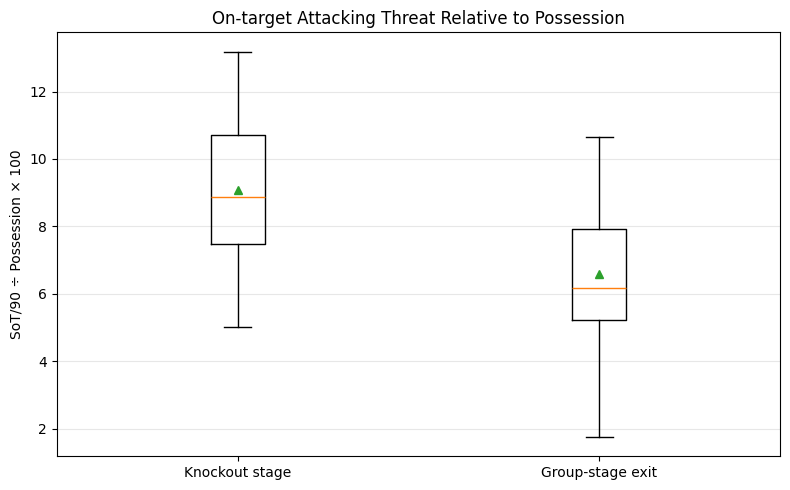

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
vals = [
    task1_sample.loc[task1_sample["Progression"] == "Knockout stage", "OnTargetThreatPerPoss"],
    task1_sample.loc[task1_sample["Progression"] == "Group-stage exit", "OnTargetThreatPerPoss"]
]
ax.boxplot(vals, tick_labels=["Knockout stage", "Group-stage exit"], showmeans=True)
ax.set_title("On-target Attacking Threat Relative to Possession")
ax.set_ylabel("SoT/90 ÷ Possession × 100")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("task1_boxplot.png", dpi=200)
plt.show()

## 10. Interpretation and limitation

Report the mean difference, 95% confidence interval, Welch t-test p-value and statistical decision.

**Football interpretation:** this metric evaluates whether teams generated on-target shooting threat efficiently relative to how much possession they had.

**Limitation:** this is an association and does not establish that attacking efficiency caused tournament progression. Opponent strength, score state and tactical context are not controlled.